<img src= "../images/classification/wine_classification_banner.jpg" width = "800">
</img>


<h2 style= "color: #800020; text-align: left; font-weight: bold;">
Wine Classification Using K-Nearest Neighbors and PCA
</h2>

<h3 style= "color: #800020; text-align: left; font-weight: bold;">
Business Understanding
</h3>

A premium wine distributor needs an automated system for classifying wines based on their chemical properties.

The objective of this analysis is to develop a machine learning classification model that can accurately identify wine classes from their chemical characteristics

The project will use Principal Component Analysis (PCA) for dimensionality reduction and K-Nearest Neighbors (KNN) for classification. Hyperparameter tuning will then be used to identify an optimal model configuration

<h3 style= "color: #E97451; text-align: left; font-weight: bold;">
1. Initial Data Inspection
</h3>

In [2]:
# Import of libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in the data
wine_df = pd.read_csv("../data/wine.csv")

In [3]:
# data inspection
wine_df.shape

(178, 14)

In [4]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
wine_df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
Initial Observations
</h4>

- The dataset contains 178 wine samples and 14 columns
- There are 13 numerical predictor features representing different chemical properties of the wines
- The `target` column is the dependent variable that represents the wine class to be predicted
- All predictor variables are stored as floating-point numbers, while the target is stored as an integer
- There are no missing values based on the initial inspection
- The features appear to have considerably different numerical scales, which will be important when preparing the data for PCA and K-Nearest Neighbors

##### Missing Values

Missing values are checked to determine whether any observations require removal or imputation before modelling.

In [7]:
wine_df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

##### Duplicate Records

Duplicate observations are checked to prevent repeated records from unnecessarily influencing the analysis and model

In [8]:
wine_df.duplicated().sum()

0

##### Target Examination

In [9]:
wine_df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [10]:
wine_df["target"].value_counts(normalize=True) * 100

target
1    39.887640
0    33.146067
2    26.966292
Name: proportion, dtype: float64

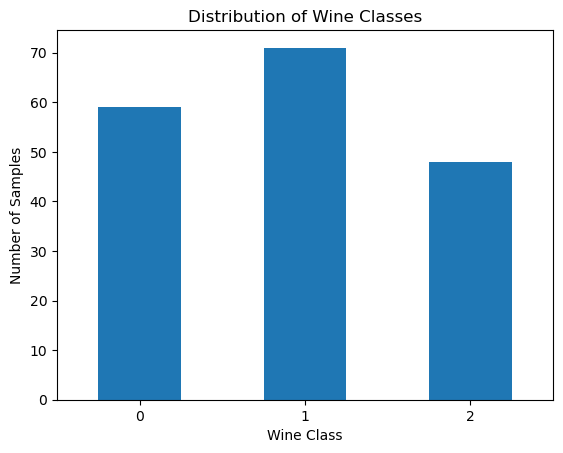

In [11]:
#visualizing the target data distribution
wine_df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [12]:
# descriptive stats
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
Data Quality Findings
</h4> 

The dataset contains no missing values and no duplicate observations. Therefore, no records need to be removed or imputed at this stage

The target variable contains three wine classes:
- Class 0: 59 samples
- Class 1: 71 samples
- Class 2: 48 samples

Although the classes are not perfectly balanced, there is no severe class imbalance. A stratified train-test split will later be used to preserve these class proportions when preparing the data for modelling

<h3 style= "color: #E97451; text-align: left; font-weight: bold;">
2. Exploratory Data Analysis
</h3> 

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
2.1. Plot Target Distribution
</h4>

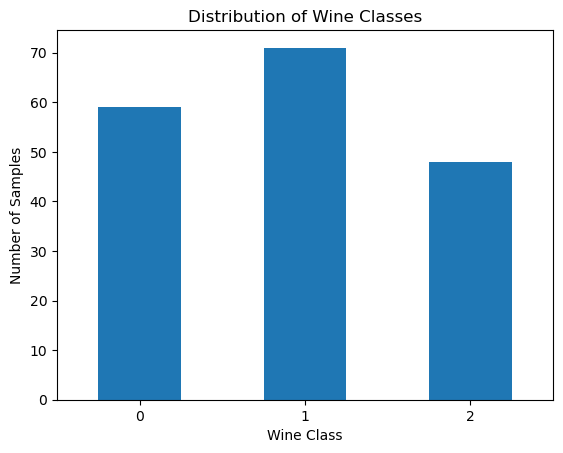

In [13]:
wine_df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
2.2. Plot Feature Distribution
</h4>

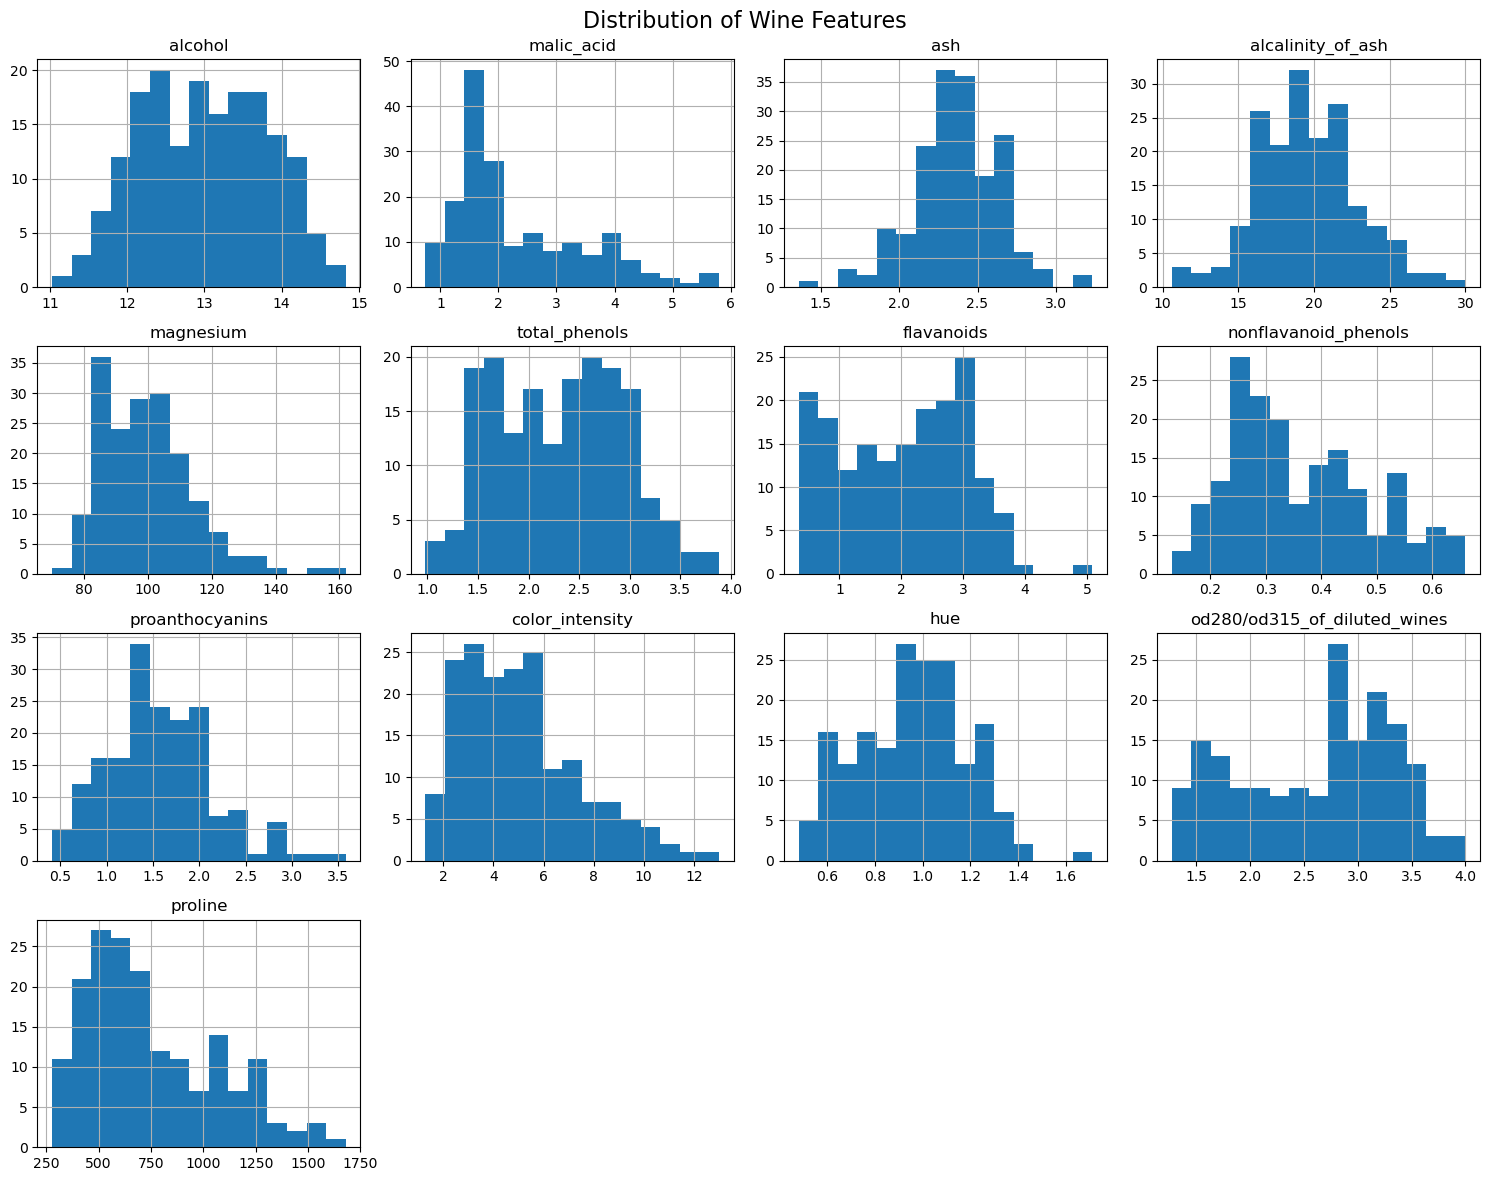

In [14]:
wine_df.drop(columns="target").hist(
    figsize=(15, 12),
    bins=15
)

plt.suptitle("Distribution of Wine Features", fontsize=16)
plt.tight_layout()
plt.show()

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
2.3. Feature Comparison Across Wine Classes
</h4>

This is done to check whether the distributions differ substantially between classes, that's evidence that these chemical properties may contain useful information for classification.

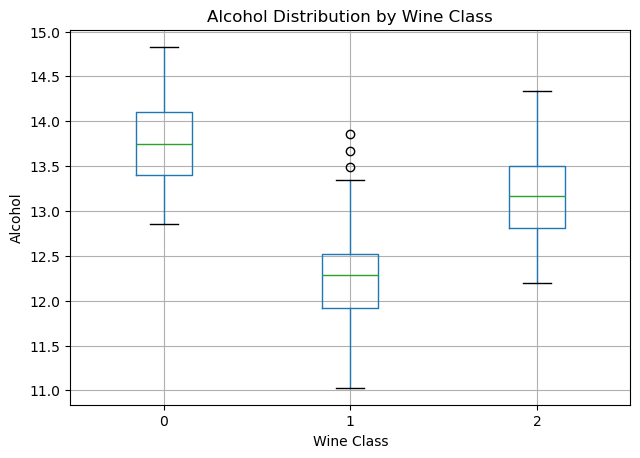

In [15]:
wine_df.boxplot(
    column="alcohol",
    by="target",
    figsize=(7, 5)
)

plt.title("Alcohol Distribution by Wine Class")
plt.suptitle("")
plt.xlabel("Wine Class")
plt.ylabel("Alcohol")
plt.show()

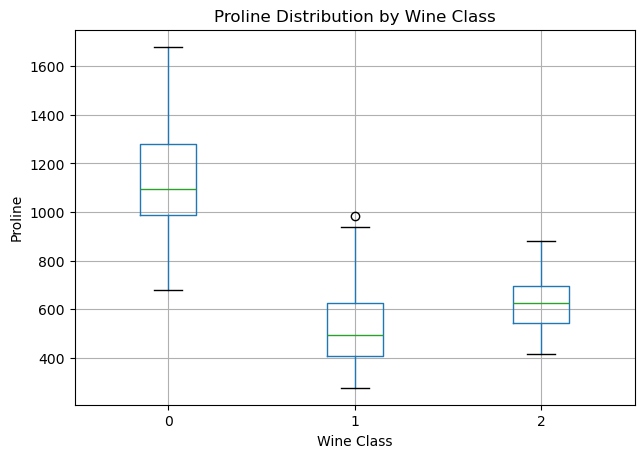

In [16]:
wine_df.boxplot(
    column="proline",
    by="target",
    figsize=(7, 5)
)

plt.title("Proline Distribution by Wine Class")
plt.suptitle("")
plt.xlabel("Wine Class")
plt.ylabel("Proline")
plt.show()

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
2.4. Correlation Matrix
</h4>

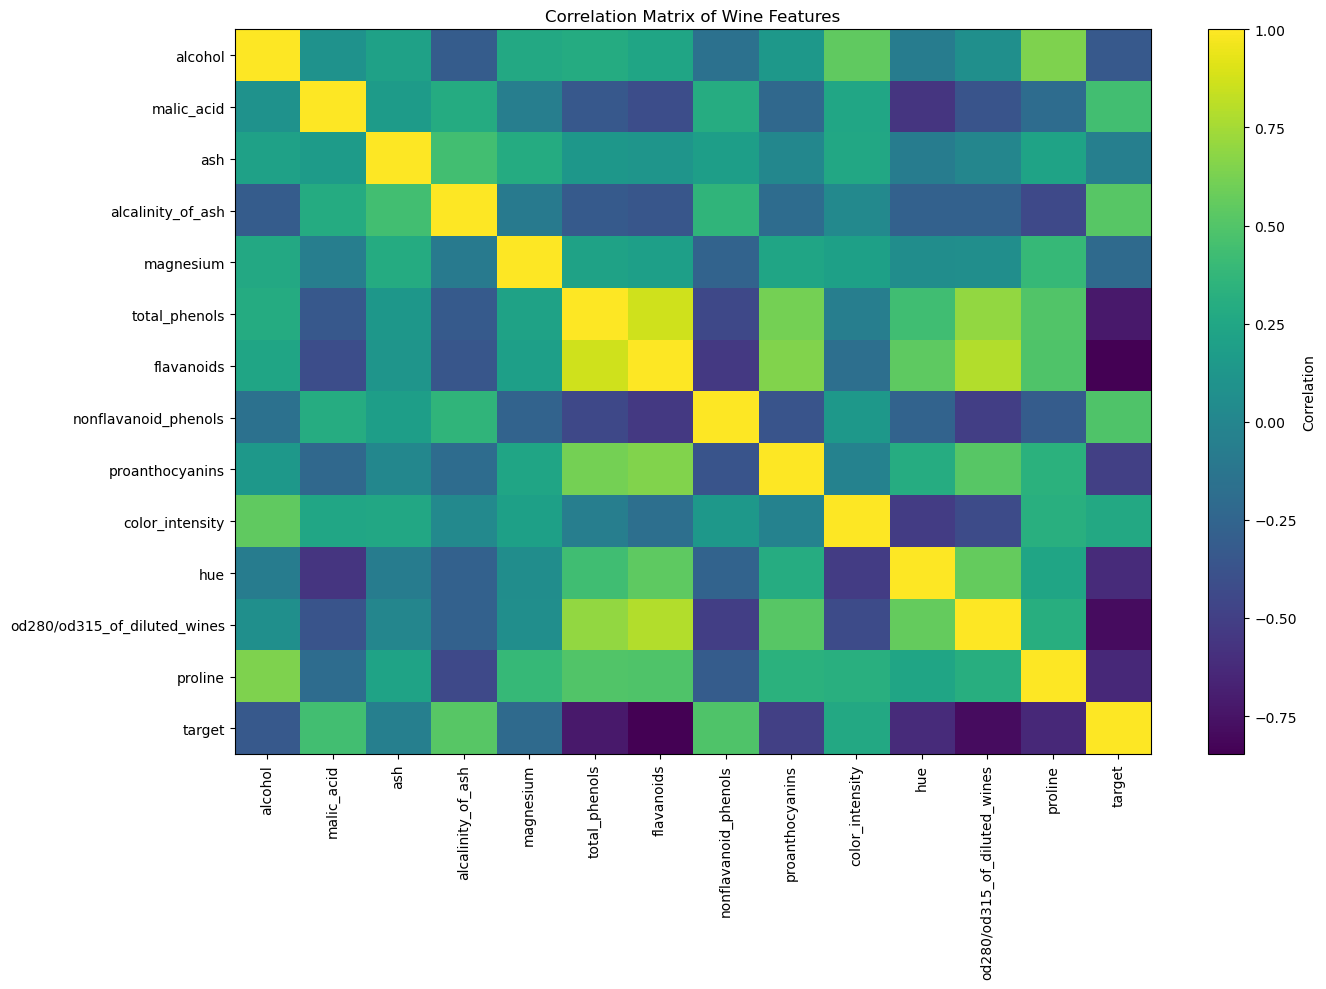

In [17]:
correlation_matrix = wine_df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Wine Features")
plt.tight_layout()
plt.show()

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
EDA Findings
</h4>

The exploratory analysis revealed several important characteristics of the dataset:

- The three wine classes are reasonably represented, although Class 1 contains the largest number of observations and Class 2 the smallest. There is no severe class imbalance
- The predictor variables operate on substantially different numerical scales. For example, `proline` contains values in the hundreds and thousands, while variables such as `hue` and `nonflavanoid_phenols` have much smaller values. Feature standardization will therefore be important before applying PCA and KNN
- Some features have approximately symmetric distributions, while others such as `malic_acid`, `color_intensity`, and `proline` show some positive skewness
- Alcohol levels differ across the three wine classes. Class 0 generally has higher alcohol levels, while Class 1 generally has lower values
- Proline also shows considerable differences between wine classes, particularly with Class 0 having substantially higher values than Classes 1 and 2
- The correlation matrix shows relationships among several chemical properties. In particular, features such as `total_phenols`, `flavanoids`, and `od280/od315_of_diluted_wines` appear positively related
- These correlations suggest that some features contain overlapping information, providing motivation for applying Principal Component Analysis (PCA) to reduce dimensionality while retaining as much useful variation as possible

<h4 style= "color: #E97451; text-align: left; font-weight: bold;">
2.1. Plot Target Distribution
</h4>